## Exploratory Data Analysis (EDA) — Four Datasets
**Notes for the Team**:
This notebook is limited to exploratory analysis of each dataset independently.

Before moving to the next phase, please review all output tables/plots and confirm:
- columns requiring cleaning,
- fields to exclude for PCA/clustering,
- and merge-key consistency risks.
This notebook performs **dataset-by-dataset EDA only**.

What we need to done after EDA:
- data cleaning
- dataset merging
- feature engineering
- ratio computation
- county-level aggregation

Datasets analyzed:
1. `EV_registration_activity.csv`
2. `EV_charger_locations.csv`
3. `cities_counties_pop.csv`
4. `median_income_by_county.xlsx`

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### The below path should be where your data is saved (e.g. my data is savd in C:\Users\alexm\Documents\GitHub\SML_group_project\data")

In [ ]:
import os
os.chdir(r"C:\Users\alexm\Documents\GitHub\SML_group_project")
print("Working directory:", os.getcwd())

Working directory: C:\Users\alexm\Documents\GitHub\SML_group_project


## EDA Functions

Set of helper functions that make the EDA cleaner & consistent across all datasets. Instead of rewriting the same code for every file, these functions handle common EDA steps such as:
- showing basic dataset structure  
- checking for missing values and suspicious zeros  
- summarizing numeric and categorical columns  
- creating simple visualizations (histograms, boxplots, bar charts)  

In [ ]:
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)


def basic_structure(df, dataset_name):
    # Quick snapshot of shape + columns
    print(f"\n===== {dataset_name}: BASIC STRUCTURE =====")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
    print("\nColumn names:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)
    print("\nFirst 5 rows:")
    display(df.head())


def missing_data_checks(df, dataset_name):
    print(f"\n===== {dataset_name}: MISSING DATA =====")

    # Missing values per column
    missing_by_col = df.isna().sum().sort_values(ascending=False)
    print("\nMissing values per column:")
    display(missing_by_col.to_frame("missing_count"))

    # Look for zero-heavy numeric columns that often indicate placeholders
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    zero_keywords = [
        'price', 'income', 'range', 'odometer', 'count',
        'total', 'level', 'fee', 'population', 'latitude', 'longitude'
    ]

    zero_flags = []
    for col in numeric_cols:
        if any(word in col.lower() for word in zero_keywords):
            zero_count = int((df[col] == 0).sum())
            if zero_count > 0:
                zero_flags.append({
                    "column": col,
                    "zero_count": zero_count,
                    "zero_pct": round(100 * zero_count / len(df), 2)
                })

    print("\nColumns with suspicious zeros (numeric):")
    if zero_flags:
        zero_df = pd.DataFrame(zero_flags).sort_values("zero_count", ascending=False)
        display(zero_df)
    else:
        print("No suspicious zero-heavy numeric columns detected with current keyword filter.")


    # Basic formatting checks on text columns
    text_cols = df.select_dtypes(include=['object', 'string']).columns
    format_flags = []

    for col in text_cols:
        values = df[col].dropna().astype(str)
        if values.empty:
            continue

        has_edge_spaces = int((values != values.str.strip()).sum())
        has_case_mismatch = int(values.str.lower().nunique() < values.nunique())

        looks_like_date = 'date' in col.lower()
        parse_fail_count = np.nan
        if looks_like_date:
            parsed = pd.to_datetime(values, errors='coerce')
            parse_fail_count = int(parsed.isna().sum())

        if has_edge_spaces > 0 or has_case_mismatch > 0 or (looks_like_date and parse_fail_count > 0):
            format_flags.append({
                "column": col,
                "leading_or_trailing_whitespace": has_edge_spaces,
                "case_inconsistency_signal": has_case_mismatch,
                "date_parse_failures_for_non_null_values": parse_fail_count,
            })

    print("\nColumns with potential inconsistent formatting:")
    if format_flags:
        display(pd.DataFrame(format_flags))
    else:
        print("No obvious formatting issues detected by the generic checks.")


def numeric_summary(df, dataset_name):
    print(f"\n===== {dataset_name}: NUMERIC SUMMARY =====")
    numeric_df = df.select_dtypes(include=[np.number])

    if numeric_df.shape[1] == 0:
        print("No numeric columns found.")
        return

    # mean, median, std, min, max
    stats = numeric_df.describe().T[['mean', '50%', 'std', 'min', 'max']]
    stats = stats.rename(columns={'50%': 'median'})
    display(stats)

    # Outliers by IQR rule
    outlier_rows = []
    for col in numeric_df.columns:
        values = numeric_df[col].dropna()
        if values.empty:
            continue

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        if iqr == 0:
            outlier_count = 0
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            outlier_count = int(((values < lower) | (values > upper)).sum())

        outlier_rows.append({
            "column": col,
            "outlier_count_iqr": outlier_count,
            "outlier_pct_iqr": round(100 * outlier_count / len(values), 2)
        })

    print("\nOutlier flags (IQR method):")
    display(pd.DataFrame(outlier_rows).sort_values("outlier_count_iqr", ascending=False))

    # Skewness
    skew_values = numeric_df.skew(numeric_only=True)
    skew_values = skew_values.sort_values(key=lambda x: x.abs(), ascending=False)
    skew_table = skew_values.rename("skewness").to_frame()
    skew_table["is_strongly_skewed_abs_gt_1"] = skew_table["skewness"].abs() > 1

    print("\nSkewness by numeric column:")
    display(skew_table)


def categorical_summary(df, dataset_name):
    print(f"\n===== {dataset_name}: CATEGORICAL SUMMARY =====")
    cat_cols = df.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()

    if len(cat_cols) == 0:
        print("No categorical columns found.")
        return

    # Number of unique values
    unique_table = pd.DataFrame({
        "column": cat_cols,
        "n_unique": [df[col].nunique(dropna=True) for col in cat_cols],
    }).sort_values("n_unique", ascending=False)

    print("\nNumber of unique categories per categorical column:")
    display(unique_table)

    # Top 10 categories
    print("\nTop 10 most frequent categories per categorical column:")
    for col in cat_cols:
        print(f"\n--- {col} ---")
        display(df[col].value_counts(dropna=False).head(10).to_frame("count"))


def plot_numeric(df, dataset_name, max_cols=8):
    print(f"\n===== {dataset_name}: NUMERIC VISUALIZATIONS =====")
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) == 0:
        print("No numeric columns found for numeric visualizations.")
        return

    cols_to_plot = numeric_cols[:max_cols]
    plot_df = df[cols_to_plot].dropna(how='all')

    # Sample very large data for faster plotting
    if len(plot_df) > 50000:
        plot_df = plot_df.sample(50000, random_state=42)

    for col in cols_to_plot:
        values = plot_df[col].dropna()
        if values.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(values, kde=True, ax=axes[0])
        axes[0].set_title(f"{dataset_name} - Histogram: {col}")

        sns.boxplot(x=values, ax=axes[1])
        axes[1].set_title(f"{dataset_name} - Boxplot: {col}")

        plt.tight_layout()
        plt.show()


def plot_categorical(df, dataset_name, max_cols=8, top_n=10):
    print(f"\n===== {dataset_name}: CATEGORICAL VISUALIZATIONS =====")
    cat_cols = df.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()

    if len(cat_cols) == 0:
        print("No categorical columns found for categorical visualizations.")
        return

    cols_to_plot = cat_cols[:max_cols]
    for col in cols_to_plot:
        top_counts = df[col].value_counts(dropna=False).head(top_n)
        if top_counts.empty:
            continue

        plt.figure(figsize=(10, 4))
        sns.barplot(x=top_counts.index.astype(str), y=top_counts.values)
        plt.title(f"{dataset_name} - Top {top_n} categories: {col}")
        plt.xticks(rotation=45, ha='right')
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()


def run_eda(df, dataset_name):
    basic_structure(df, dataset_name)
    missing_data_checks(df, dataset_name)
    numeric_summary(df, dataset_name)
    categorical_summary(df, dataset_name)
    plot_numeric(df, dataset_name)
    plot_categorical(df, dataset_name)

## Dataset 1 — EV Registration Activity

### EDA Execution


===== EV Registration Activity: BASIC STRUCTURE =====
Shape: 1,738,602 rows x 33 columns

Column names:
['Clean Alternative Fuel Vehicle Type', 'VIN (1-10)', 'DOL Vehicle ID', 'Model Year', 'Make', 'Model', 'Primary Use', 'Electric Range', 'Odometer Reading', 'Odometer Reading Description', 'New or Used Vehicle', 'Sale Price', 'Sale Date', 'Transaction Type', 'Transaction Date', 'Year', 'County', 'City', 'State', 'Postal Code', '2019 HB 2042: Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Meets 2019 HB 2042 Electric Range Requirement', 'Meets 2019 HB 2042 Sale Date Requirement', 'Meets 2019 HB 2042 Sale Price/Value Requirement', '2019 HB 2042: Battery Range Requirement', '2019 HB 2042: Purchase Date Requirement', '2019 HB 2042: Sale Price/Value Requirement', 'Electric Vehicle Fee Paid', 'Transportation Electrification Fee Paid', 'Hybrid Vehicle Electrification Fee Paid', '2020 GEOID', 'Legislative District', 'Electric Utility']

Data types:
Clean Alternative Fuel Vehicle Type   

,Clean Alternative Fuel Vehicle Type,VIN (1-10),DOL Vehicle ID,Model Year,Make,Model,Primary Use,Electric Range,Odometer Reading,Odometer Reading Description,New or Used Vehicle,Sale Price,Sale Date,Transaction Type,Transaction Date,Year,County,City,State,Postal Code,2019 HB 2042: Clean Alternative Fuel Vehicle (CAFV) Eligibility,Meets 2019 HB 2042 Electric Range Requirement,Meets 2019 HB 2042 Sale Date Requirement,Meets 2019 HB 2042 Sale Price/Value Requirement,2019 HB 2042: Battery Range Requirement,2019 HB 2042: Purchase Date Requirement,2019 HB 2042: Sale Price/Value Requirement,Electric Vehicle Fee Paid,Transportation Electrification Fee Paid,Hybrid Vehicle Electrification Fee Paid,2020 GEOID,Legislative District,Electric Utility
0,Plug-in Hybrid Electric Vehicle (PHEV),5UXTS1C06L,120402992,2020,BMW,X3,Passenger,17.0,41,Actual Mileage,New,"$49,944","August 06, 2020",Original Title,"September 03, 2020",2020,King,SAMMAMISH,WA,98074.0,HB 2042 Eligibility Requirements not met,False,True,False,Battery range is too low,Purchase date requirement is met,The sale price is too high,Not Applicable,Not Applicable,Not Applicable,5.303303e+10,45.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
1,Plug-in Hybrid Electric Vehicle (PHEV),5UXTS1C06L,120402992,2020,BMW,X3,Passenger,17.0,0,Odometer reading is not collected at time of r...,Used,$0,NaN,Registration Renewal,"July 20, 2021",2021,King,SAMMAMISH,WA,98074.0,HB 2042 Eligibility Requirements not met,False,False,False,Battery range is too low,This transaction type is not eligible for the ...,This transaction type is not eligible for the ...,No,No,Yes,5.303303e+10,45.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
2,Plug-in Hybrid Electric Vehicle (PHEV),5UXTS1C06L,120402992,2020,BMW,X3,Passenger,17.0,0,Odometer reading is not collected at time of r...,Used,$0,NaN,Original Registration,"September 03, 2020",2020,King,SAMMAMISH,WA,98074.0,HB 2042 Eligibility Requirements not met,False,False,False,Battery range is too low,This transaction type is not eligible for the ...,This transaction type is not eligible for the ...,No,No,No,5.303303e+10,45.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
3,Battery Electric Vehicle (BEV),7PDSGABA1P,261413484,2023,RIVIAN,R1S,Passenger,0.0,0,Odometer reading is not collected at time of r...,Used,$0,NaN,Original Registration,"February 02, 2024",2024,King,SEATTLE,WA,98125.0,HB 2042 Eligibility Requirements not met,True,False,False,Battery range requirement is met,This transaction type is not eligible for the ...,This transaction type is not eligible for the ...,No,No,No,5.303300e+10,46.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
4,Battery Electric Vehicle (BEV),7PDSGABA1P,261413484,2023,RIVIAN,R1S,Passenger,0.0,0,Odometer reading is not collected at time of r...,Used,$0,NaN,Registration Renewal,"January 06, 2025",2025,King,SEATTLE,WA,98125.0,HB 2042 Eligibility Requirements not met,True,False,False,Battery range requirement is met,This transaction type is not eligible for the ...,This transaction type is not eligible for the ...,Yes,Yes,No,5.303300e+10,46.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)



===== EV Registration Activity: MISSING DATA =====

Missing values per column:


,missing_count
Sale Date,1267309
Transportation Electrification Fee Paid,91031
Hybrid Vehicle Electrification Fee Paid,91031
Legislative District,7103
Postal Code,124
2020 GEOID,124
County,124
Electric Range,21
State,1
Clean Alternative Fuel Vehicle Type,0



Columns with suspicious zeros (numeric):


...


--- Hybrid Vehicle Electrification Fee Paid ---


,count
Hybrid Vehicle Electrification Fee Paid,
No,1131767
Not Applicable,420846
Yes,94958
NaN,91031



--- Electric Utility ---


,count
Electric Utility,
PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),633094
PUGET SOUND ENERGY INC,347915
CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),308311
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF CLARK COUNTY - (WA),99063
BONNEVILLE POWER ADMINISTRATION||CITY OF TACOMA - (WA)||PENINSULA LIGHT COMPANY,79558
PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM COUNTY,40529
BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||INLAND POWER & LIGHT COMPANY,27410
BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOHOMISH COUNTY,15296
PACIFICORP,13478



===== EV Registration Activity: NUMERIC VISUALIZATIONS =====


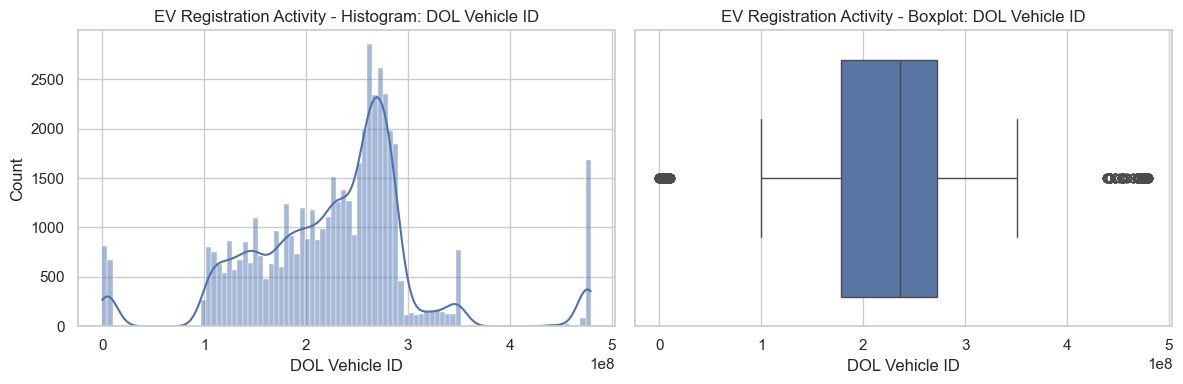

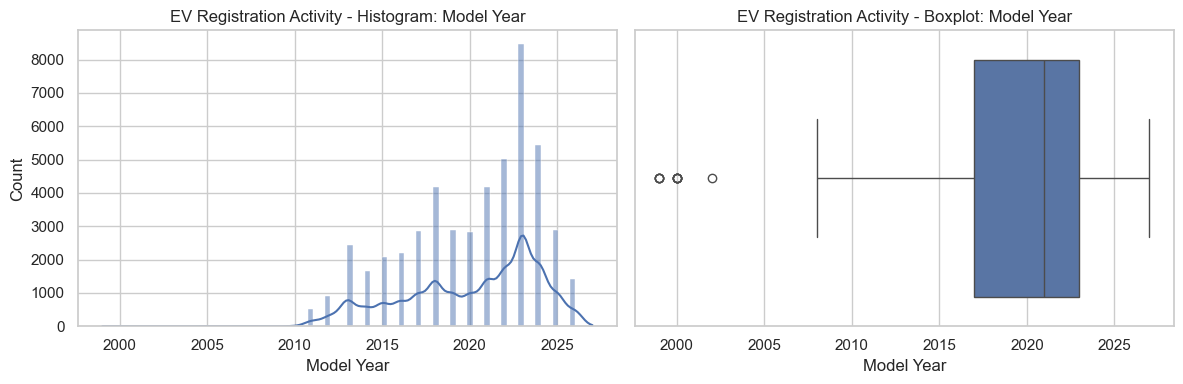

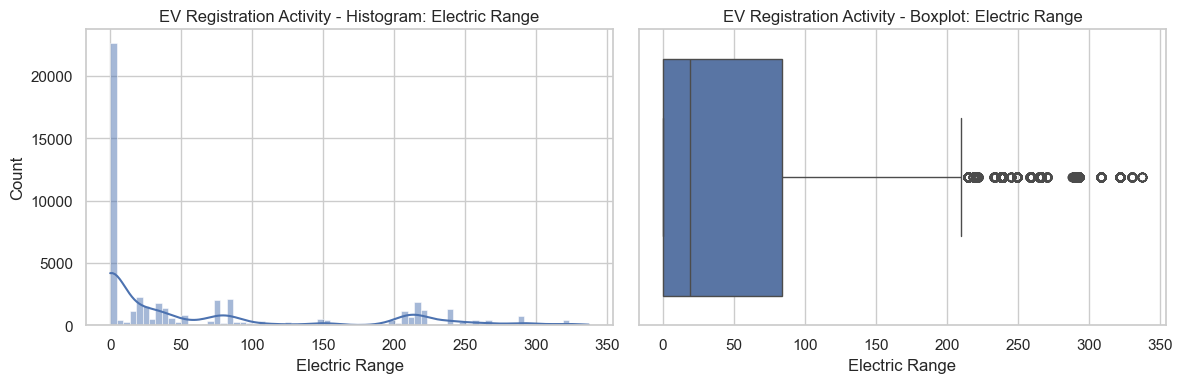

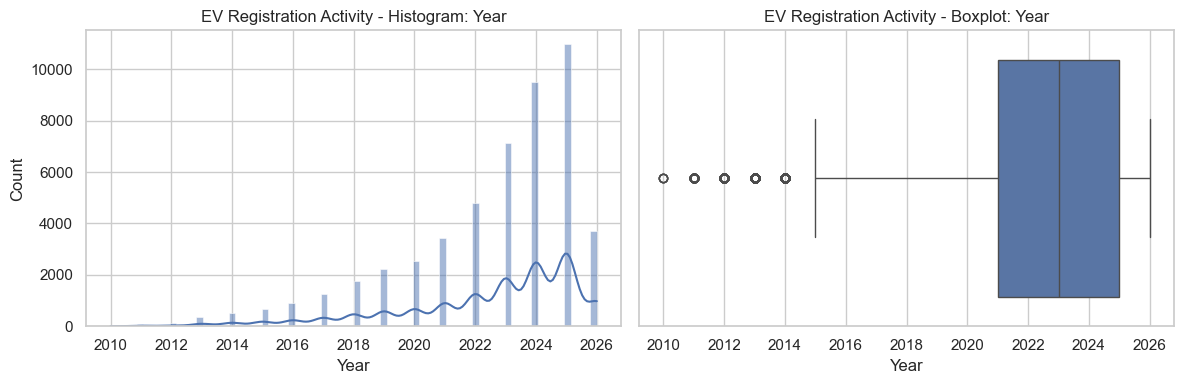

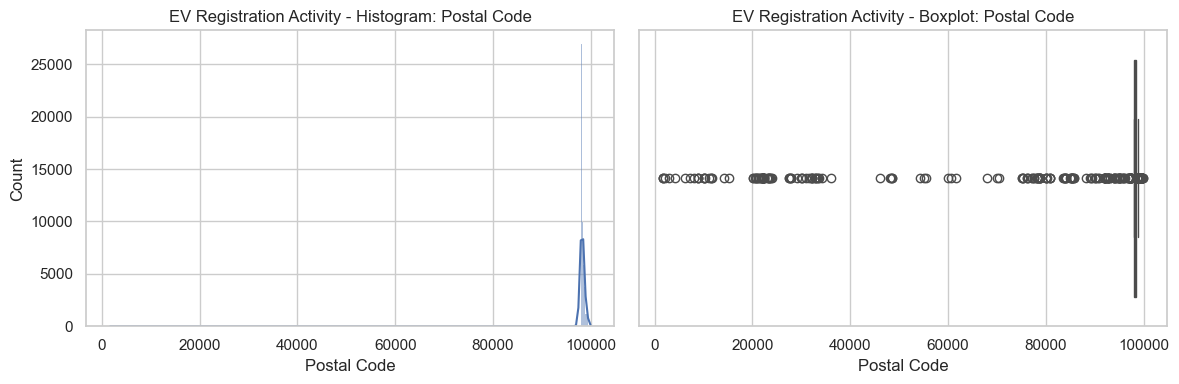

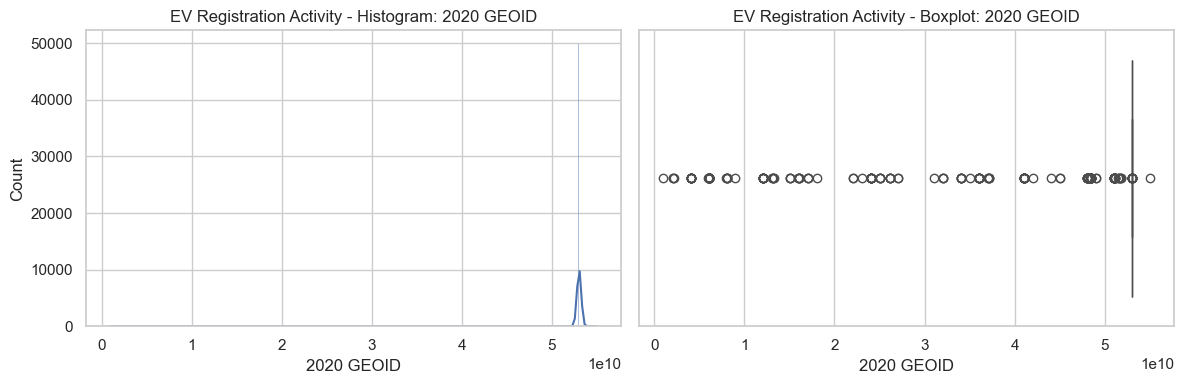

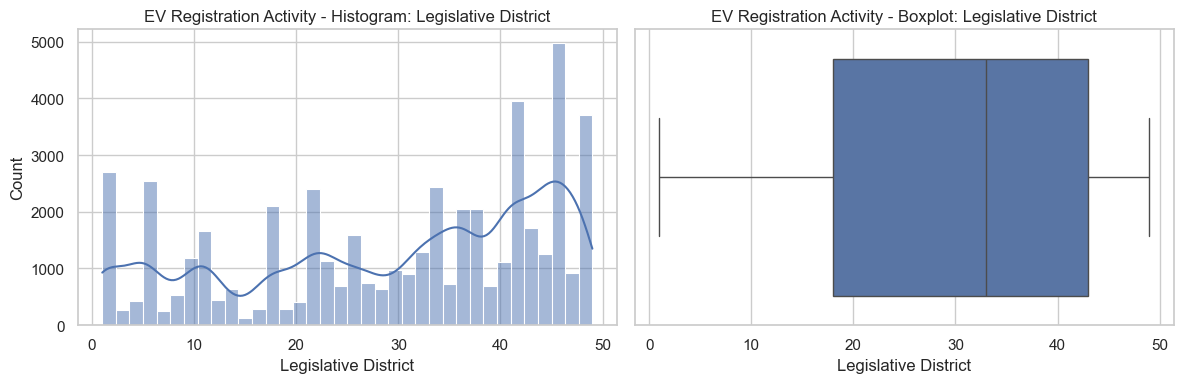


===== EV Registration Activity: CATEGORICAL VISUALIZATIONS =====


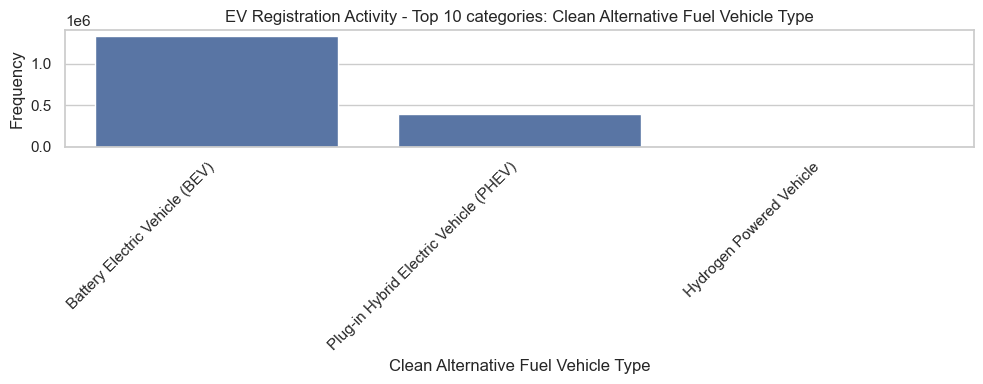

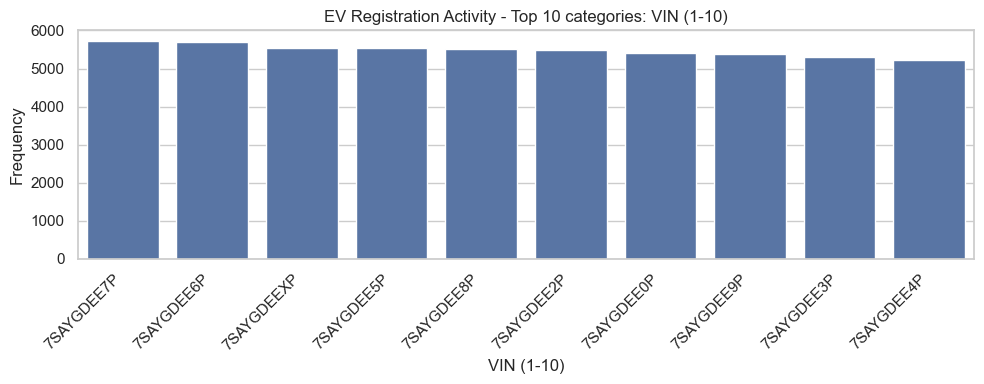

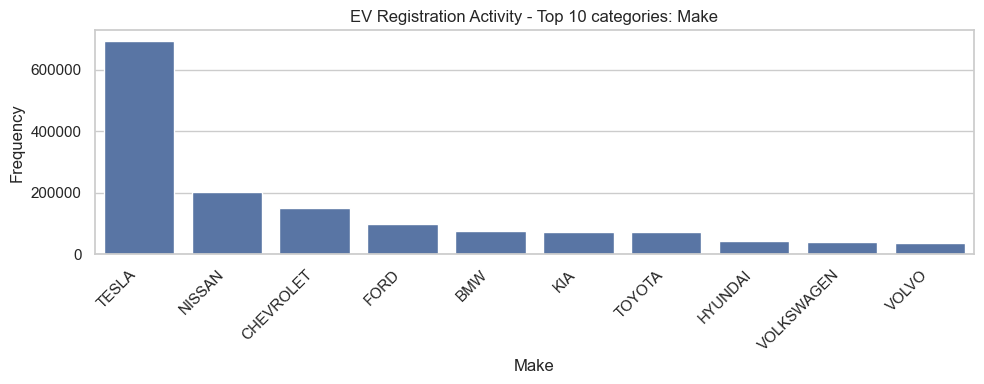

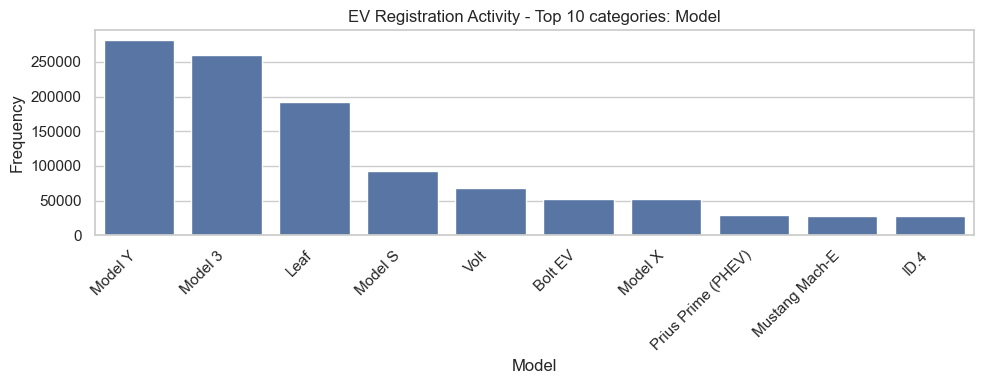

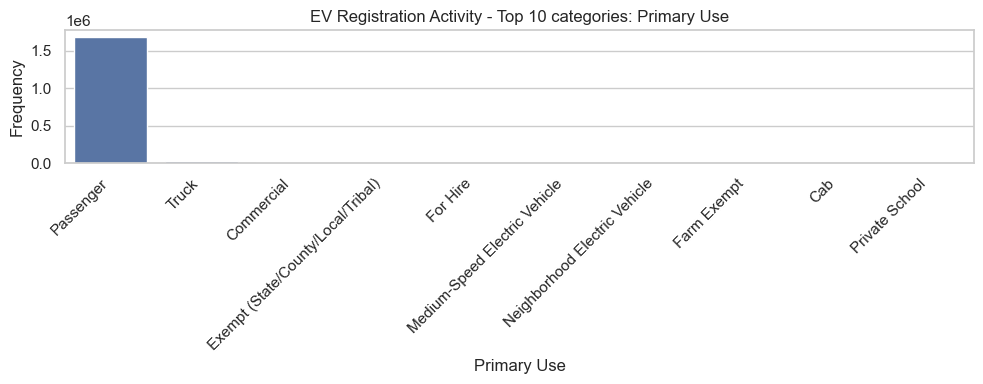

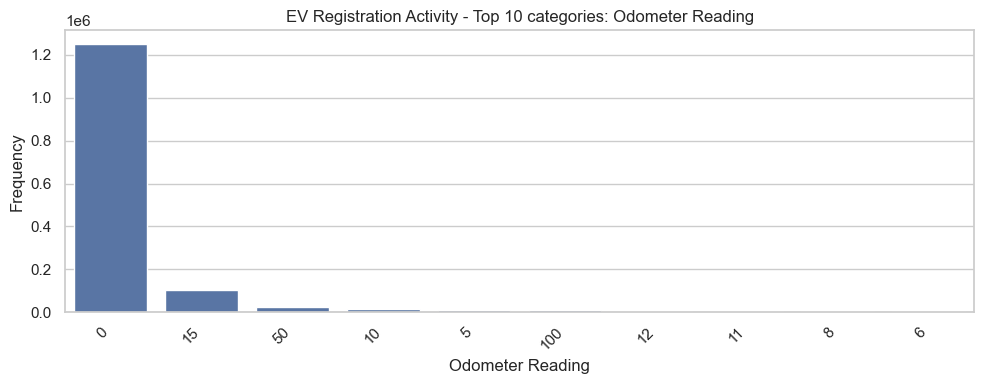

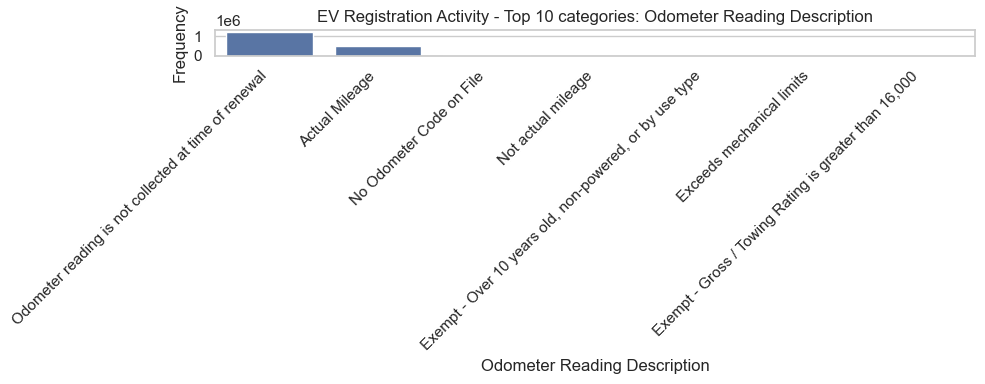

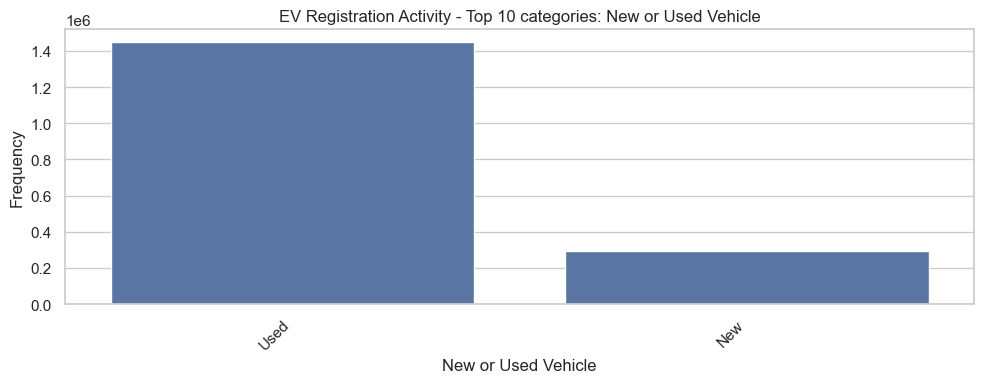

In [4]:
ev_reg = pd.read_csv('data/EV_registration_activity.csv', low_memory=False)
run_eda(ev_reg, 'EV Registration Activity')

### Data Quality Observations (to review)

- Potential issues to verify: missing values, zero-heavy numeric fields (especially transaction/sale-related), and date parsing inconsistencies.
- City/county consistency checks to inspect from outputs: naming variants, capitalization, trailing spaces, abbreviations.
- Fields likely to need cleaning later: identifiers, dates stored as text, and highly sparse fields.
- Fields likely irrelevant for PCA/clustering (without transformation): unique IDs, VIN fragment, high-cardinality text labels, and raw timestamps.

### Notes for Future Merging (after data clearning)

- Candidate merge keys later: `county`, `city`, `state_of_residence`, seem like 0.15% are registered to states other than WA.
- Potential merge problems later: inconsistent place names.
- Candidate fields for future final features: transaction counts, EV type mix, other summaries, and perhaps using some policy eligibility indicators?.

## Dataset 2 — EV Charger Locations

### EDA Execution


===== EV Charger Locations: BASIC STRUCTURE =====
Shape: 1,928 rows x 42 columns

Column names:
['X', 'Y', 'FID', 'OBJECTID', 'Station_Na', 'Station_Id', 'Fuel_Type', 'facility_t', 'Access_Hou', 'Current_St', 'Accessabil', 'Access_Det', 'Restricted', 'Payment_Me', 'Date_Last_', 'Date_Las_1', 'Open_Date', 'Availabili', 'Zipcode_Ro', 'Address', 'City', 'Zipcode', 'State', 'Country', 'Latitude', 'Longitude', 'Directions', 'Federal_Ow', 'Phone_Numb', 'Ownership_', 'EV_Network', 'EV_Netwo_1', 'EV_Level1_', 'EV_Level2_', 'EV_DC_Fast', 'Total_Leve', 'EV_Other_E', 'EV_Connect', 'EV_Netwo_2', 'EV_Pricing', 'EV_Renewab', 'Geocode_St']

Data types:
X             float64
Y             float64
FID             int64
OBJECTID        int64
Station_Na     object
Station_Id      int64
Fuel_Type      object
facility_t     object
Access_Hou     object
Current_St     object
Accessabil     object
Access_Det     object
Restricted     object
Payment_Me     object
Date_Last_     object
Date_Las_1     object
O

,X,Y,FID,OBJECTID,Station_Na,Station_Id,Fuel_Type,facility_t,Access_Hou,Current_St,Accessabil,Access_Det,Restricted,Payment_Me,Date_Last_,Date_Las_1,Open_Date,Availabili,Zipcode_Ro,Address,City,Zipcode,State,Country,Latitude,Longitude,Directions,Federal_Ow,Phone_Numb,Ownership_,EV_Network,EV_Netwo_1,EV_Level1_,EV_Level2_,EV_DC_Fast,Total_Leve,EV_Other_E,EV_Connect,EV_Netwo_2,EV_Pricing,EV_Renewab,Geocode_St
0,-1.360096e+07,6.059126e+06,1,1601,ASPECT ASPCT AT TOTEM,235493,ELEC,,24 hours daily,E,Public,,,,2023/08/07 00:00:00+00,2023/08/07 00:00:00+00,2022/11/01 00:00:00+00,NaN,,12540 120th Ave NE,Kirkland,98034,WA,US,47.712309,-122.179514,,,888-758-4389,,USCPIL12866511,ChargePoint Network,0,2,0,2,,J1772,http://www.chargepoint.com/,,,GPS
1,-1.359663e+07,6.072514e+06,2,1201,KING COUNTY WTD BRIGHTWATER - 2,197831,ELEC,,24 hours daily,E,Public,,,,2023/08/07 00:00:00+00,2023/08/07 00:00:00+00,2021/10/16 00:00:00+00,NaN,,22503 WA-9,Woodinville,98072,WA,US,47.793168,-122.140579,,,888-758-4389,,USCPIL8742311,ChargePoint Network,0,2,0,2,,J1772,http://www.chargepoint.com/,,,GPS
2,-1.305638e+07,6.050033e+06,3,1602,SPOKANE HYUNDAI SPOKANE HYUNDAI,235496,ELEC,,24 hours daily,T,Public,,,,2023/08/07 00:00:00+00,2023/08/07 00:00:00+00,2022/11/01 00:00:00+00,2023/02/23 00:00:00+00,,8801 E Sprague Ave,Spokane Valley,99212,WA,US,47.657317,-117.287492,,,888-758-4389,,USCPIL13021791,ChargePoint Network,0,1,0,1,,J1772,http://www.chargepoint.com/,,,GPS
3,-1.359663e+07,6.072502e+06,4,1202,KING COUNTY WTD BRIGHTWATER - 4,197832,ELEC,,24 hours daily,E,Public,,,,2023/08/07 00:00:00+00,2023/08/07 00:00:00+00,2021/10/16 00:00:00+00,NaN,,22503 WA-9,Woodinville,98072,WA,US,47.793094,-122.140577,,,888-758-4389,,USCPIL8742351,ChargePoint Network,0,2,0,2,,J1772,http://www.chargepoint.com/,,,GPS
4,-1.308445e+07,6.044697e+06,5,1603,SIA E GARAGE F.2 #2,235500,ELEC,,24 hours daily,E,Public,,,,2023/08/07 00:00:00+00,2023/08/07 00:00:00+00,2022/11/01 00:00:00+00,NaN,,9000 W. Airport Drive,Airway Heights,99224,WA,US,47.625021,-117.539657,,,888-758-4389,,USCPIL13092571,ChargePoint Network,0,2,0,2,,J1772,http://www.chargepoint.com/,,,GPS



===== EV Charger Locations: MISSING DATA =====

Missing values per column:


,missing_count
Availabili,1785
Date_Last_,9
Open_Date,2
FID,0
Station_Na,0
Station_Id,0
Fuel_Type,0
OBJECTID,0
X,0
Y,0



Columns with suspicious zeros (numeric):


...


--- EV_Renewab ---


,count
EV_Renewab,
,1918
HYDRO,7
SOLAR,2
NONE,1



--- Geocode_St ---


,count
Geocode_St,
GPS,1721
200-9,146
200-8,59
200-6,2



===== EV Charger Locations: NUMERIC VISUALIZATIONS =====


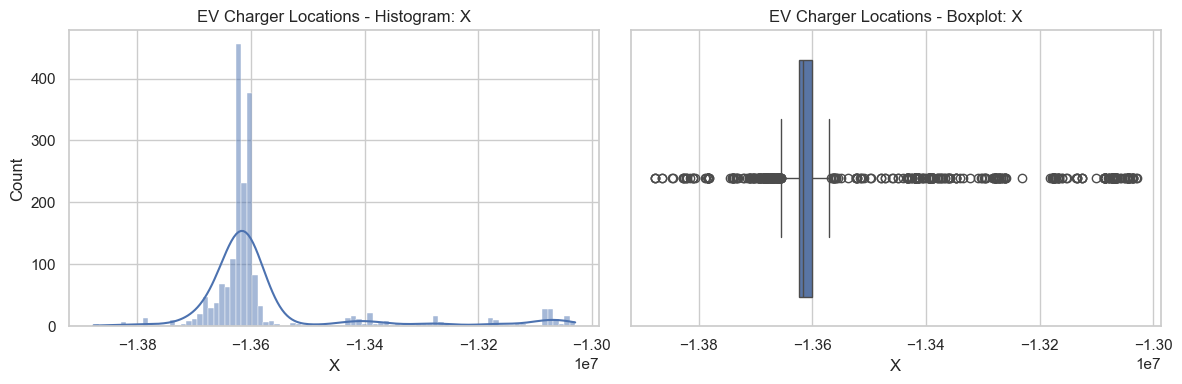

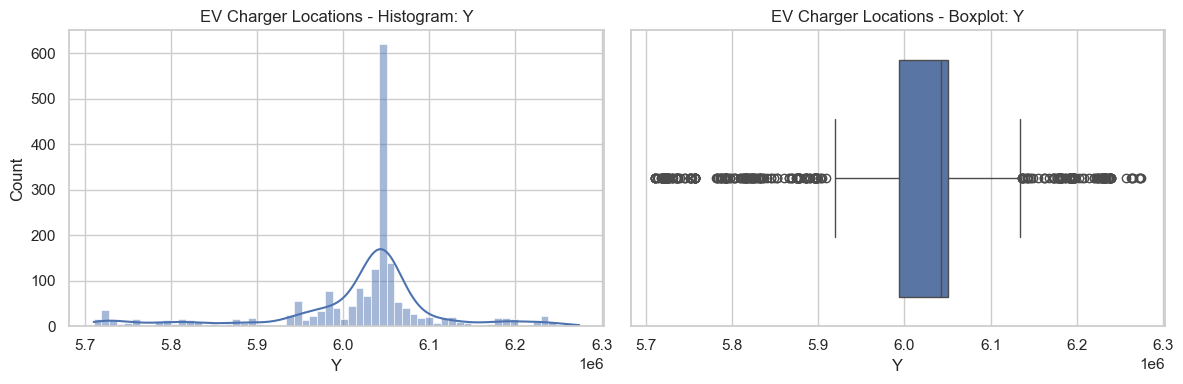

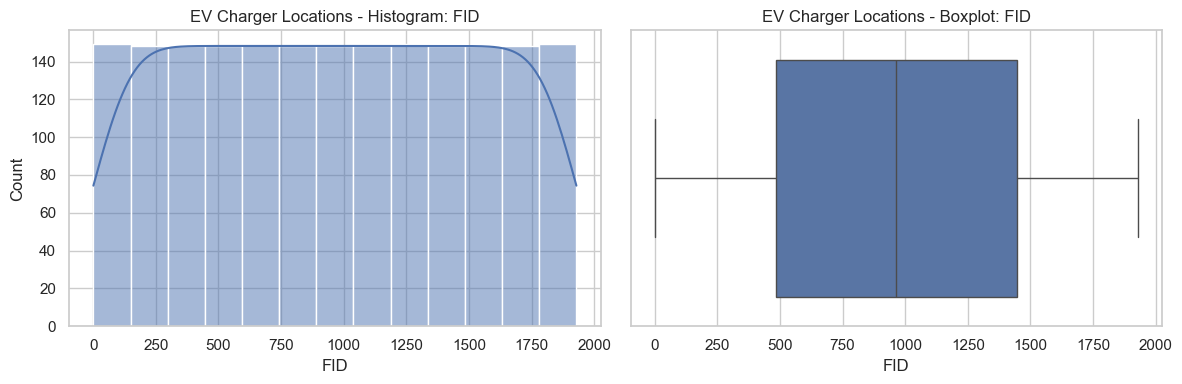

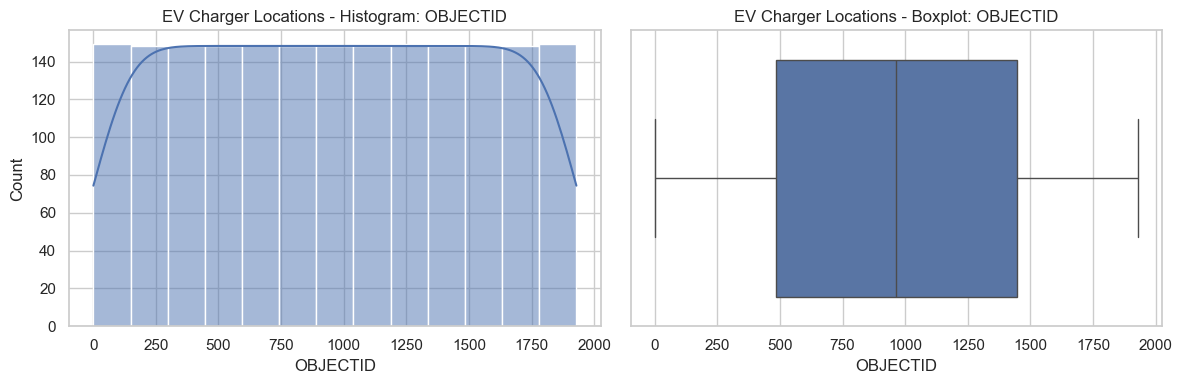

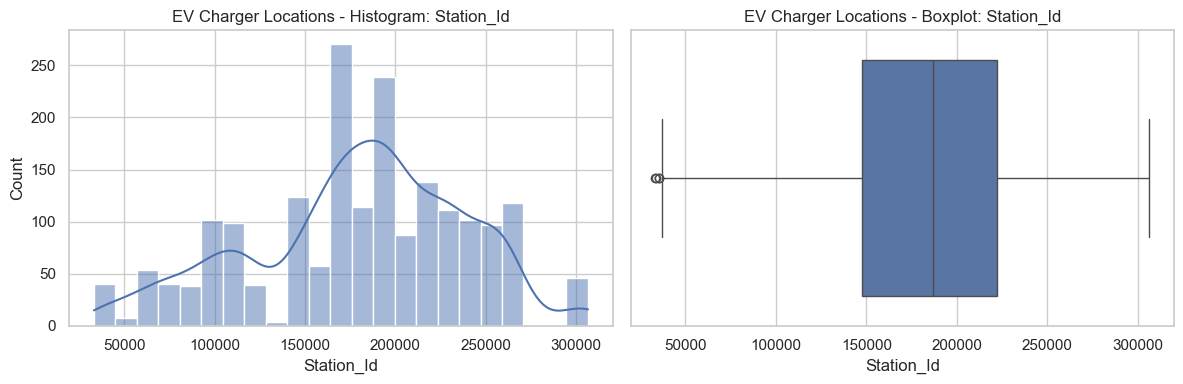

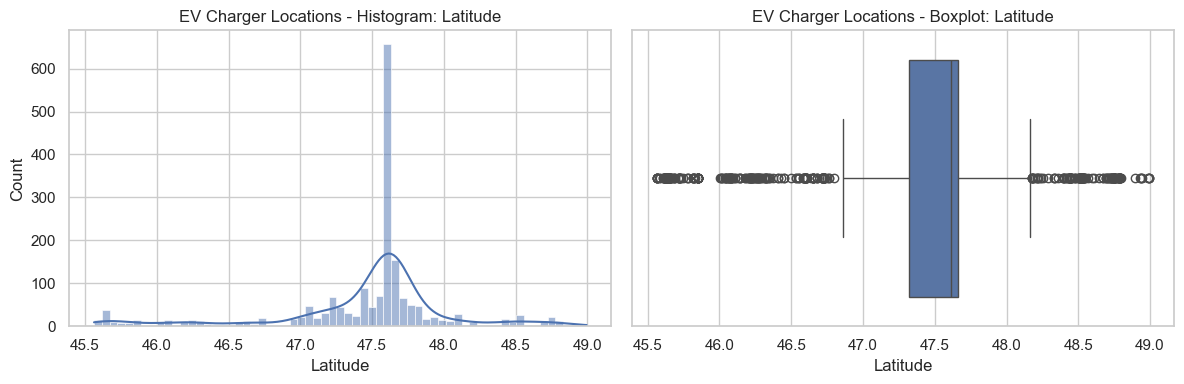

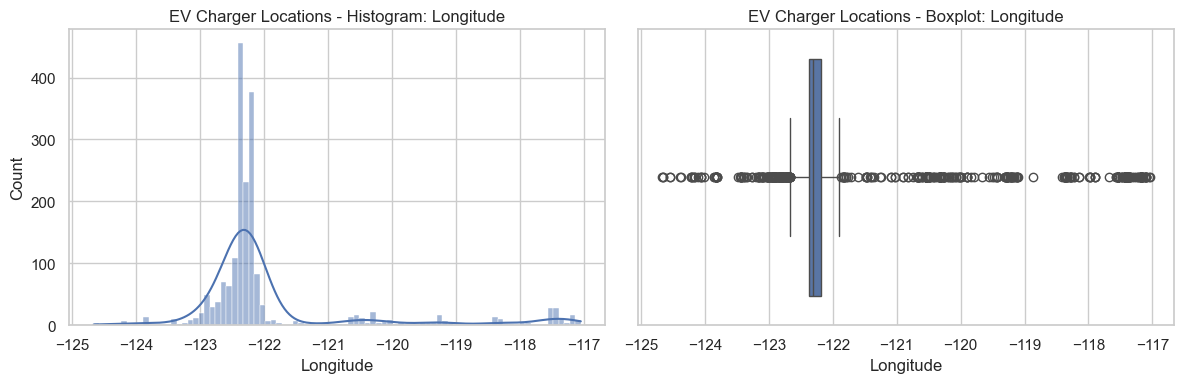

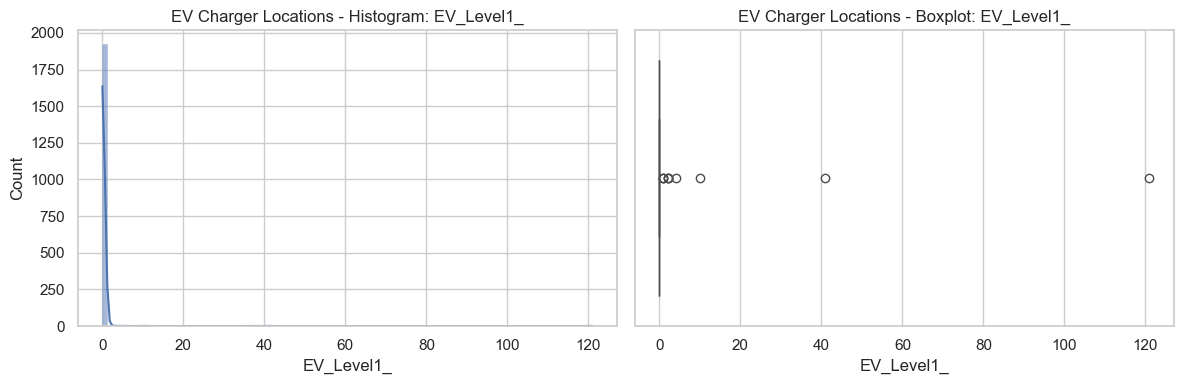


===== EV Charger Locations: CATEGORICAL VISUALIZATIONS =====


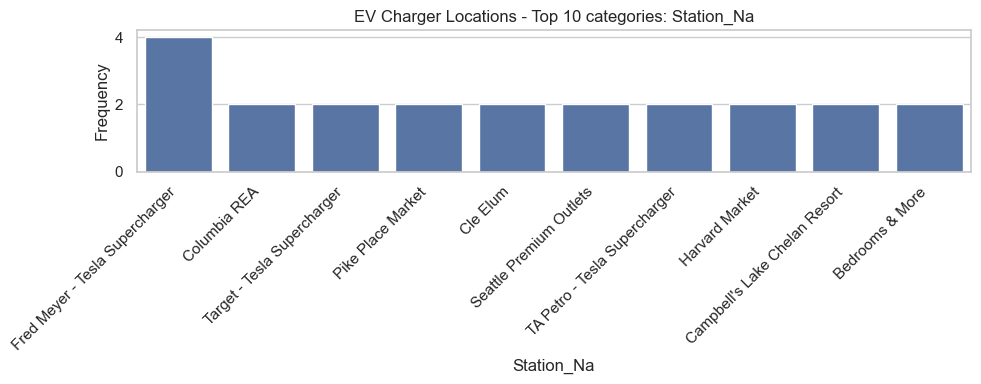

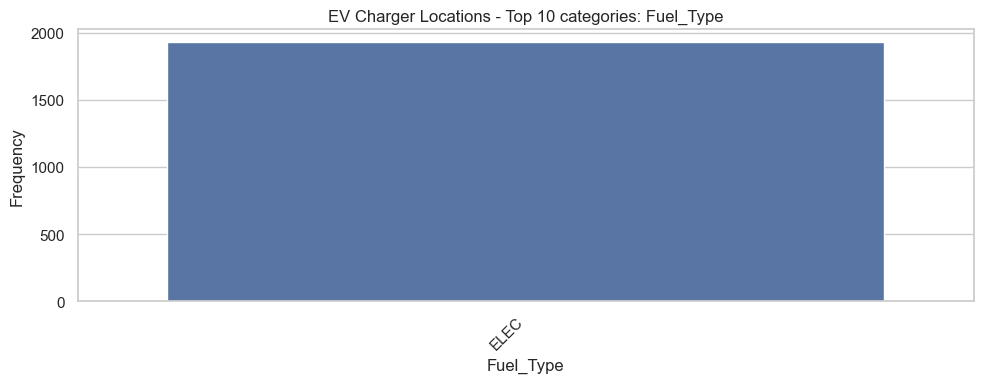

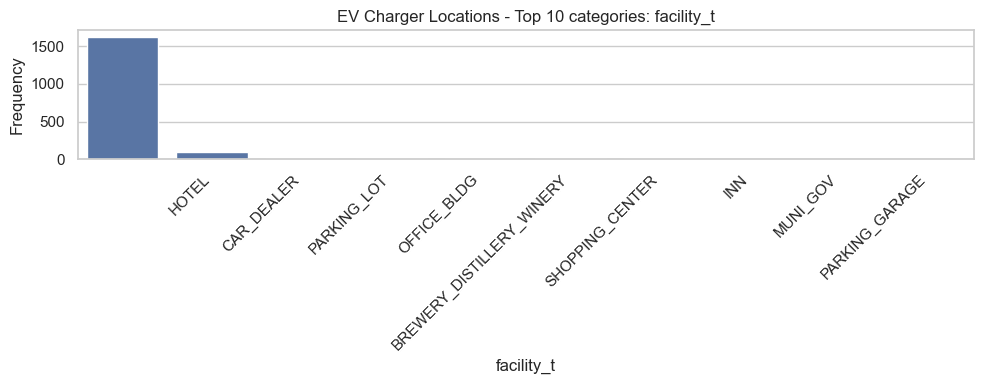

C:\Users\alexm\AppData\Local\Temp\ipykernel_31812\1659952827.py:209: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


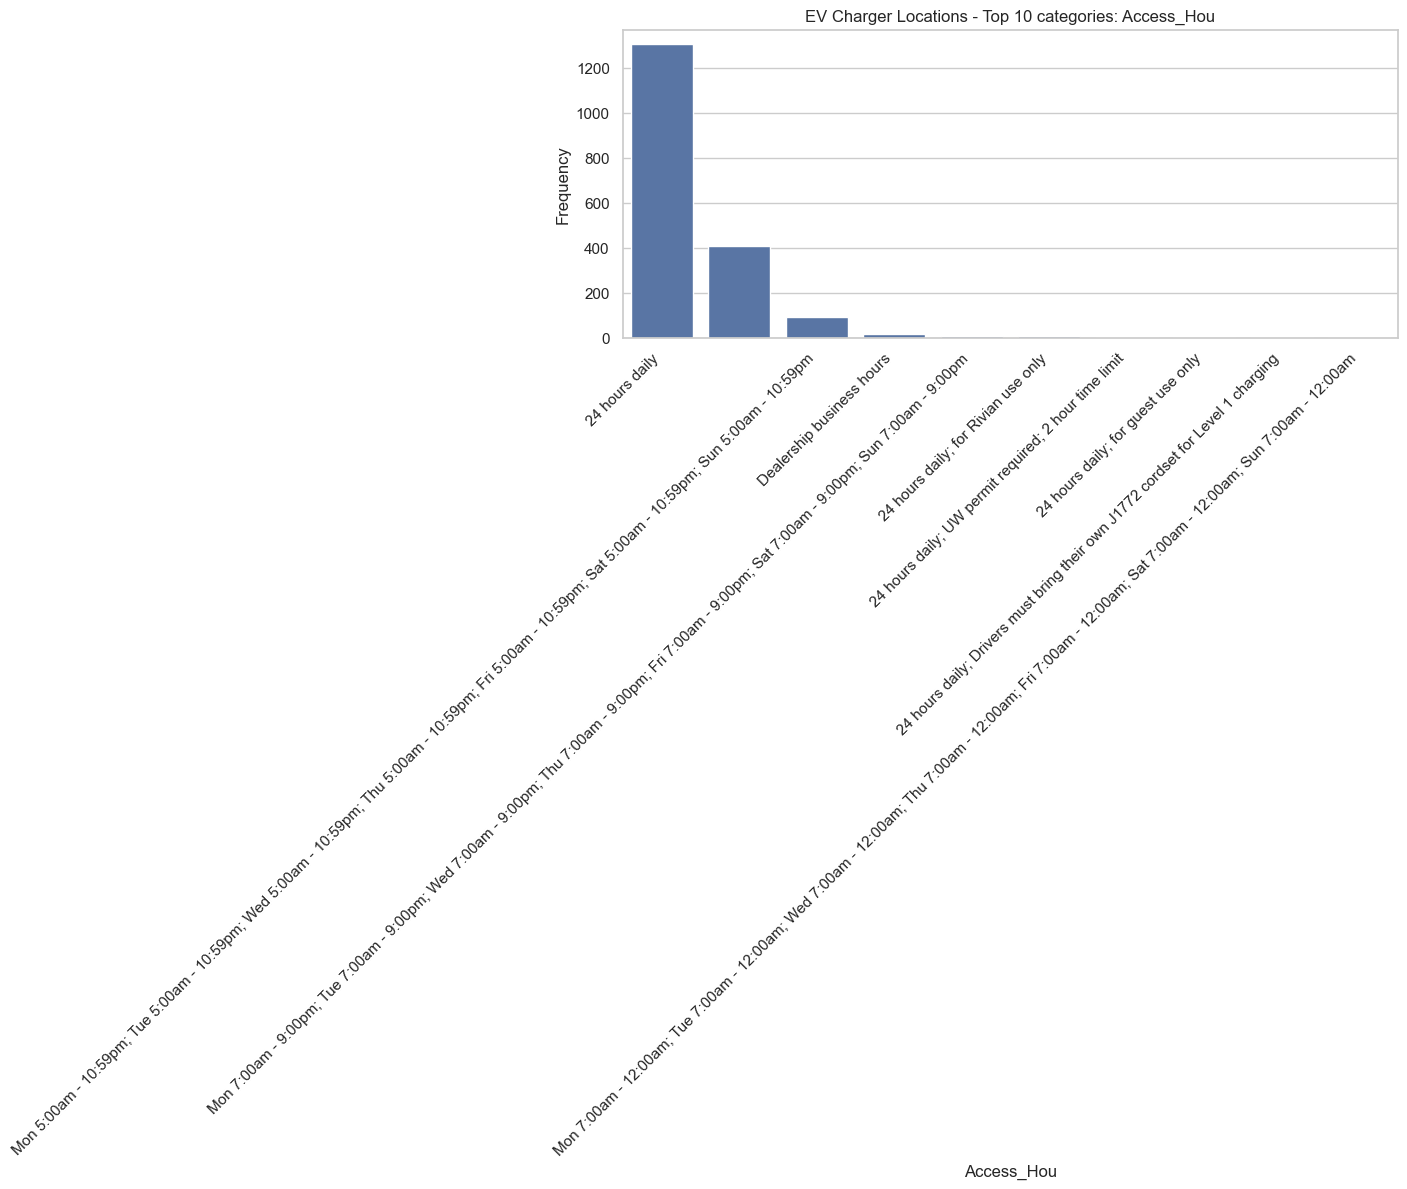

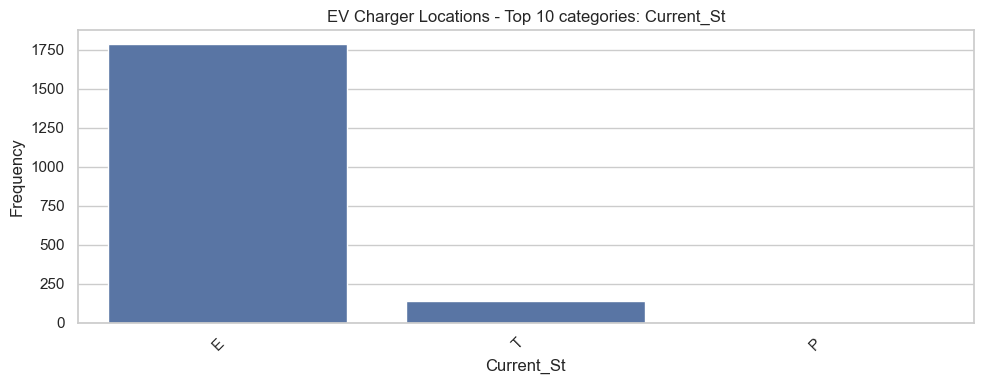

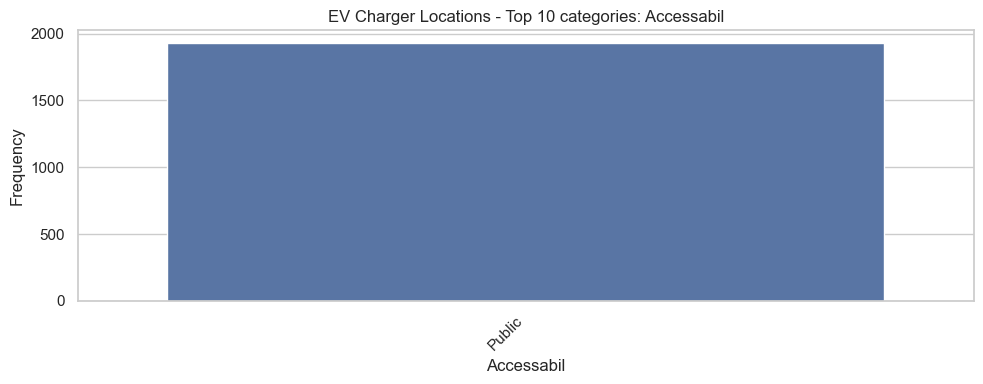

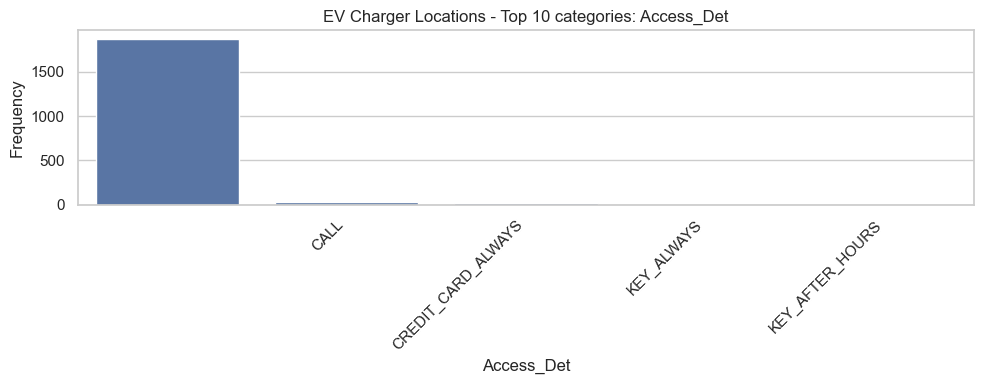

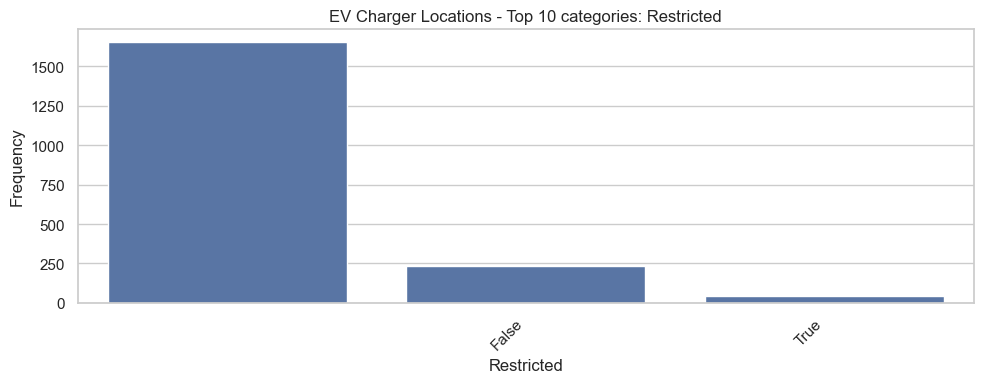

In [5]:
ev_charger = pd.read_csv('data/EV_charger_locations.csv', low_memory=False)
run_eda(ev_charger, 'EV Charger Locations')

### Data Quality Observations (to review after running outputs)

- Potential issues to verify: missingness in station metadata, zero-heavy charger-count fields, and invalid/missing coordinates.
- City/county consistency checks to inspect from outputs: city naming variants and ZIP inconsistencies.

**This dataset does not include county information. Therefore, should we verify whether the ZIP codes for the cities are accurate, or should we assume the data is correct and match the counties based on the cities?**

- Fields likely to need cleaning later: access/payment free text, status coding, network naming variants, and date field consistency.
- Fields likely irrelevant for PCA/clustering (without transformation): station identifiers, names, phone/address text, and URL-like fields.

### Notes for Future Merging (after data cleaning)

- Candidate merge keys later: `City`, `County`.
- Potential merge problems later: inconsistent city/ZIP text formatting and coordinate precision differences.
- Candidate fields for future final features: charger counts (`EV_Level1_`, `EV_Level2_`, `EV_DC_Fast`, `Total_Leve`), network/access indicators, and station status fields.

## Dataset 3 — Cities / Counties Population

### EDA Execution


===== Cities Counties Population: BASIC STRUCTURE =====
Shape: 244 rows x 5 columns

Column names:
['City', 'Population_2025', 'County', 'Class', 'Form_of_Government']

Data types:
City                  object
Population_2025        int64
County                object
Class                 object
Form_of_Government    object
dtype: object

First 5 rows:


,City,Population_2025,County,Class,Form_of_Government
0,Aberdeen,17200,Grays Harbor,First,Mayor-Council
1,Airway Heights,12120,Spokane,Code,Council-Manager
2,Albion,545,Whitman,Town,Mayor-Council
3,Algona,3335,King,Code,Mayor-Council
4,Almira,315,Lincoln,Town,Mayor-Council



===== Cities Counties Population: MISSING DATA =====

Missing values per column:


,missing_count
City,0
Population_2025,0
County,0
Class,0
Form_of_Government,0



Columns with suspicious zeros (numeric):
No suspicious zero-heavy numeric columns detected with current keyword filter.

Columns with potential inconsistent formatting:
No obvious formatting issues detected by the generic checks.

===== Cities Counties Population: NUMERIC SUMMARY =====


...


--- Class ---


,count
Class,
Code,175
Town,57
First,8
Second,4



--- Form_of_Government ---


,count
Form_of_Government,
Mayor-Council,198
Council-Manager,46



===== Cities Counties Population: NUMERIC VISUALIZATIONS =====


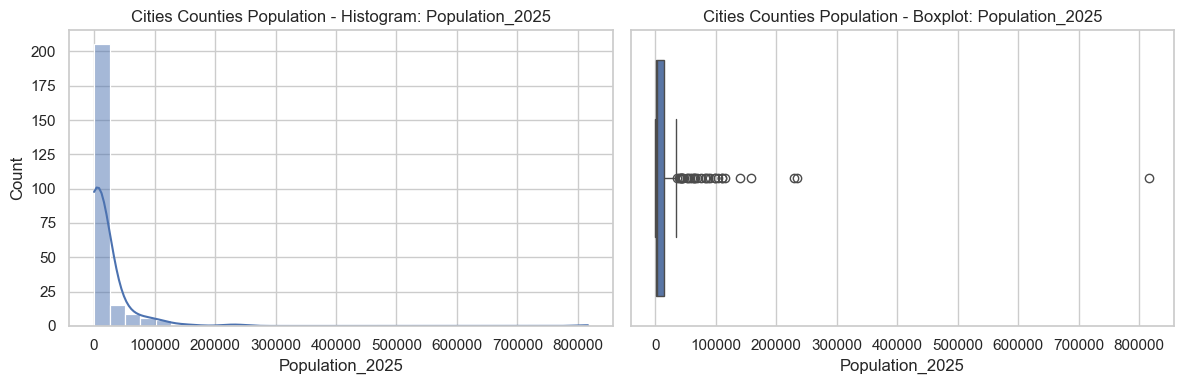


===== Cities Counties Population: CATEGORICAL VISUALIZATIONS =====


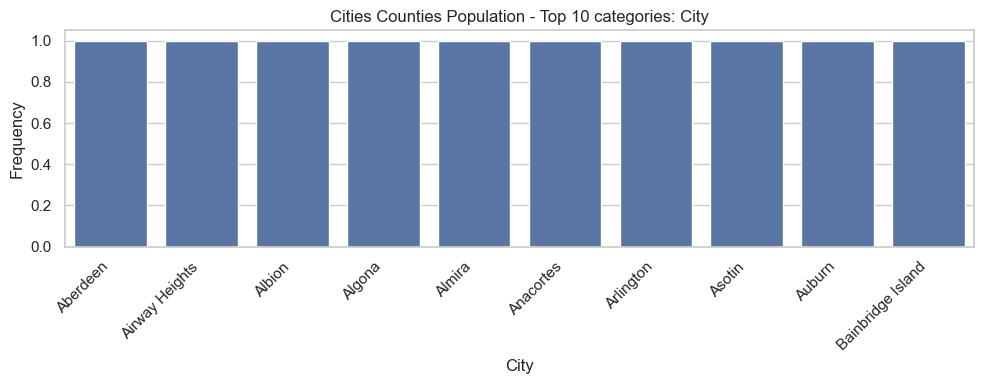

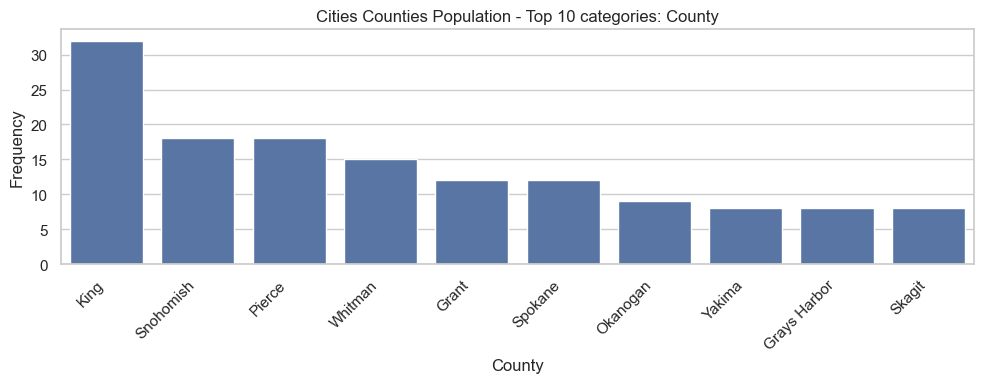

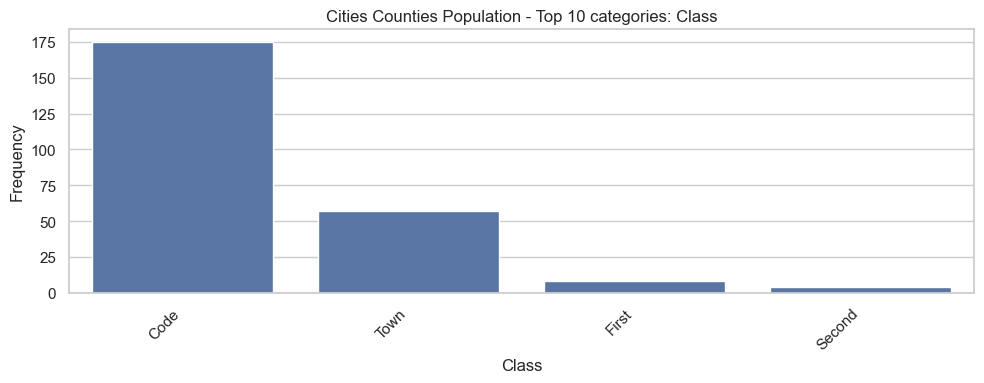

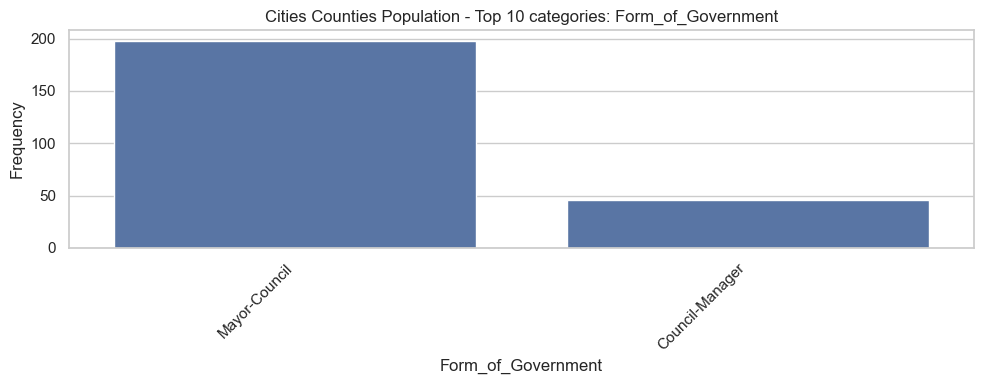

In [6]:
cities_counties_pop = pd.read_csv('data/cities_counties_pop.csv', low_memory=False)
run_eda(cities_counties_pop, 'Cities Counties Population')

### Data Quality Observations (to review)

- Potential issues to verify: missing/zero population fields, duplicate place records, and inconsistent county/city formatting.
- City/county consistency checks to inspect from outputs: spelling variants, case differences, and suffix/prefix differences.
- Fields likely to need cleaning later: text standardization for city/county names and numeric parsing consistency.
- Fields likely irrelevant for PCA/clustering (without transformation): purely descriptive identifiers or labels with no analytical variation.

### Notes for Future Merging (after data cleaning)

- Candidate merge keys later: county/city name fields and any available FIPS/GEOID-like identifiers.
- Potential merge problems later: name mismatches across datasets and non-unique city names across counties.
- Candidate fields for future final features: population magnitude and density-related fields (if present) after validation/standardization.

## Dataset 4 — Median Income by County

### EDA Execution


===== Median Income by County: BASIC STRUCTURE =====
Shape: 39 rows x 16 columns

Column names:
['County', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

Data types:
County     object
2011      float64
2012      float64
2013      float64
2014      float64
2015      float64
2016      float64
2017      float64
2018      float64
2019      float64
2020      float64
2021      float64
2022      float64
2023      float64
2024      float64
2025      float64
dtype: object

First 5 rows:


,County,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Adams,41068.44,42353.54,43541.08,45711.82,47645.73,49501.39,48848.79,52870.06,53535.0,56421.0,57405.0,62410.0,67056.00,72047.86,69332.46
1,Asotin,40171.03,41703.24,42173.78,43367.86,46107.27,47020.11,51766.88,50746.37,54776.0,53377.0,56438.0,65625.0,67820.20,63963.65,75647.31
2,Benton,60608.28,62739.22,63709.96,63157.40,62071.02,62282.05,63501.71,67912.30,72847.0,75882.0,77339.0,85144.0,87992.12,80987.99,95571.93
3,Chelan,46274.71,47265.40,51712.87,50825.03,53067.96,55109.14,60790.91,60747.40,59838.0,61546.0,64700.0,81697.0,84429.81,76794.05,84324.53
4,Clallam,38885.97,41886.68,44823.81,45453.82,46240.92,48187.11,47766.59,55664.09,57571.0,54712.0,62623.0,66693.0,68923.92,67451.14,78138.51



===== Median Income by County: MISSING DATA =====

Missing values per column:


,missing_count
County,0
2011,0
2012,0
2013,0
2014,0
2015,0
2016,0
2017,0
2018,0
2019,0



Columns with suspicious zeros (numeric):
No suspicious zero-heavy numeric columns detected with current keyword filter.

Columns with potential inconsistent formatting:
No obvious formatting issues detected by the generic checks.

===== Median Income by County: NUMERIC SUMMARY =====


...


===== Median Income by County: CATEGORICAL SUMMARY =====

Number of unique categories per categorical column:


,column,n_unique
0,County,39



Top 10 most frequent categories per categorical column:

--- County ---


,count
County,
Adams,1
Asotin,1
Benton,1
Chelan,1
Clallam,1
Clark,1
Columbia,1
Cowlitz,1
Douglas,1



===== Median Income by County: NUMERIC VISUALIZATIONS =====


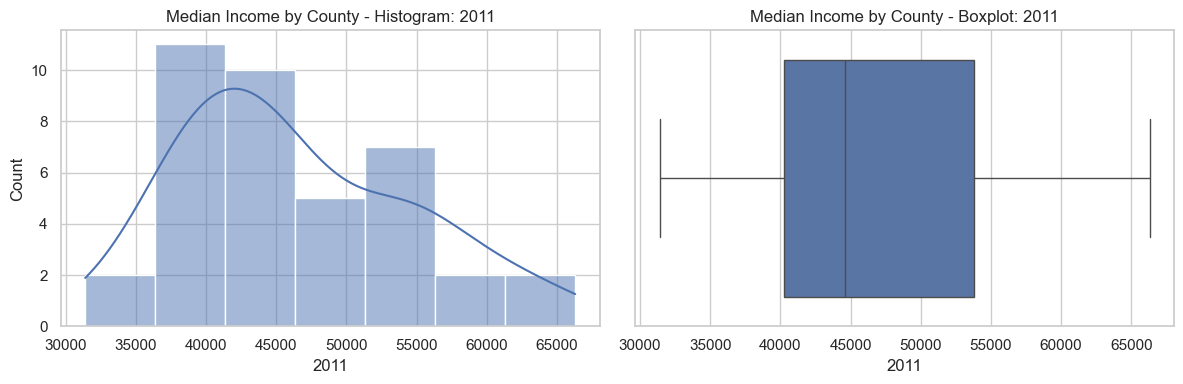

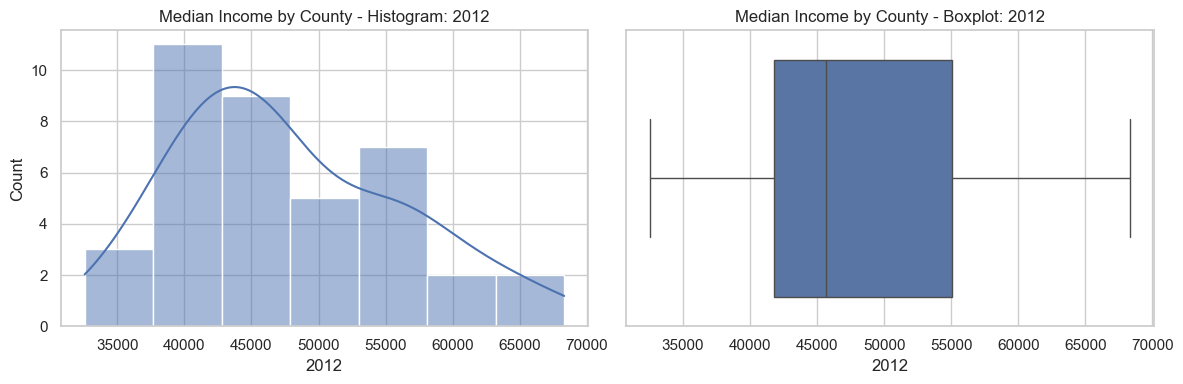

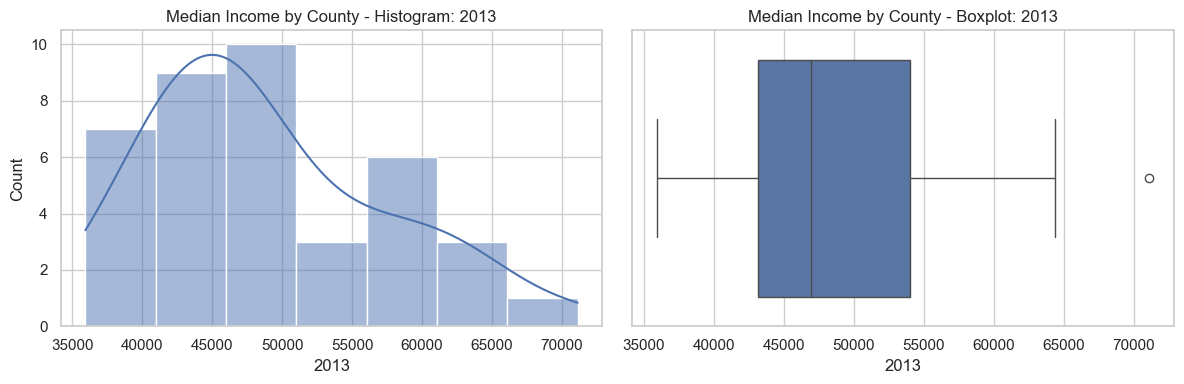

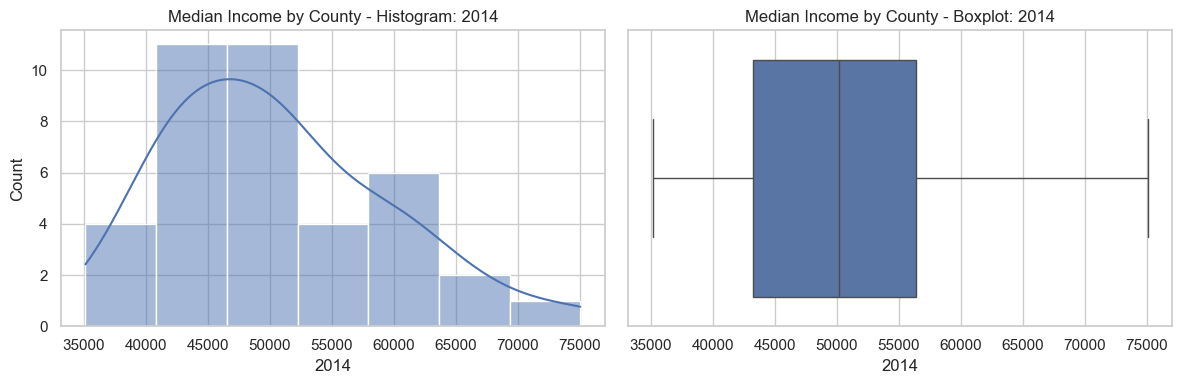

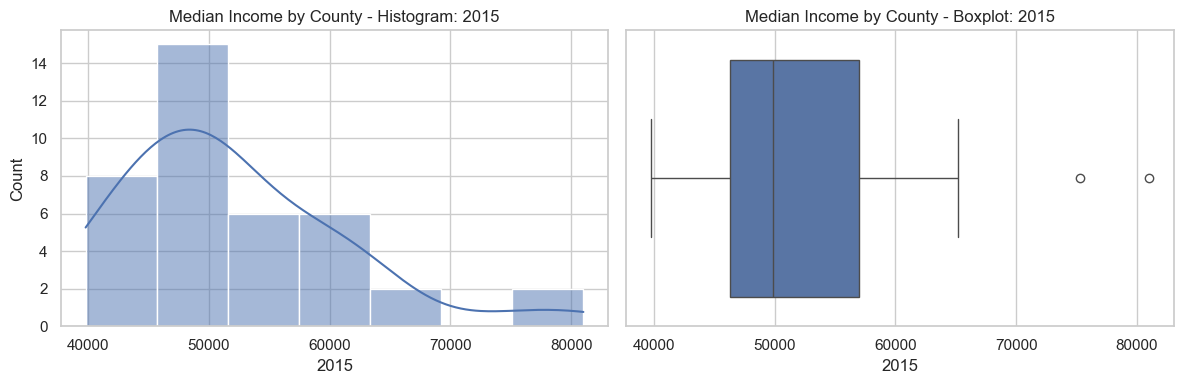

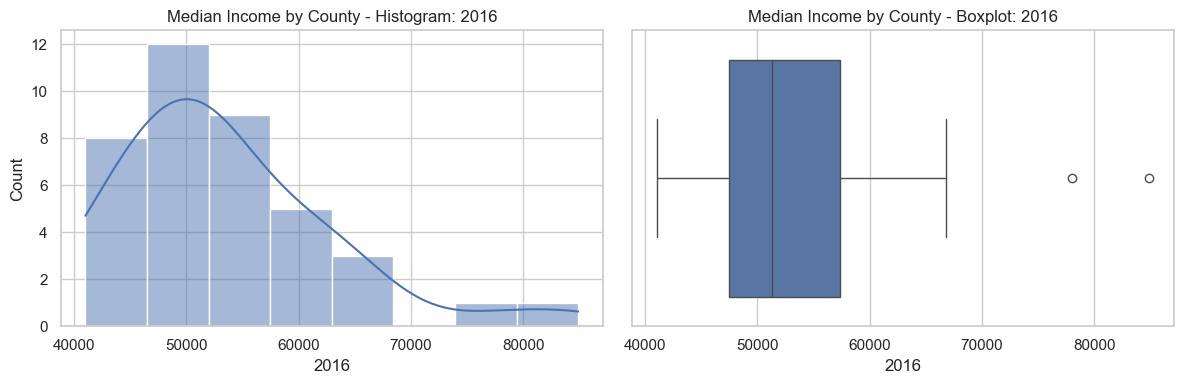

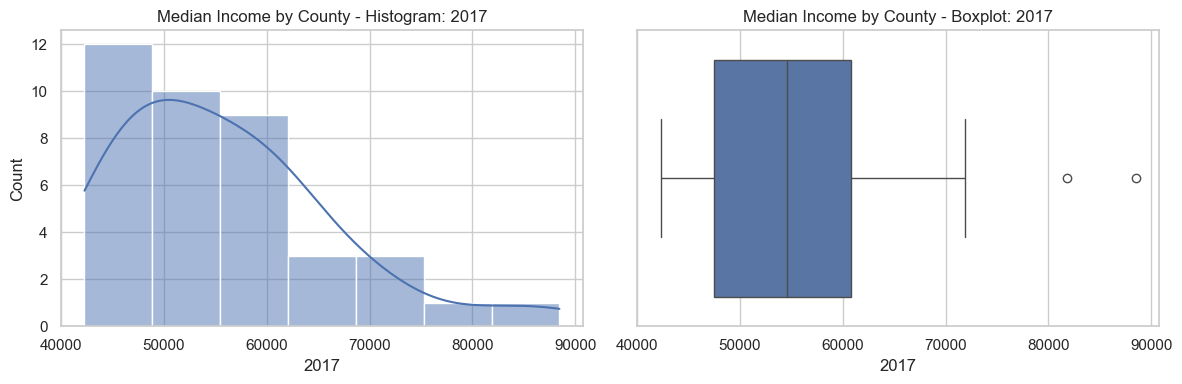

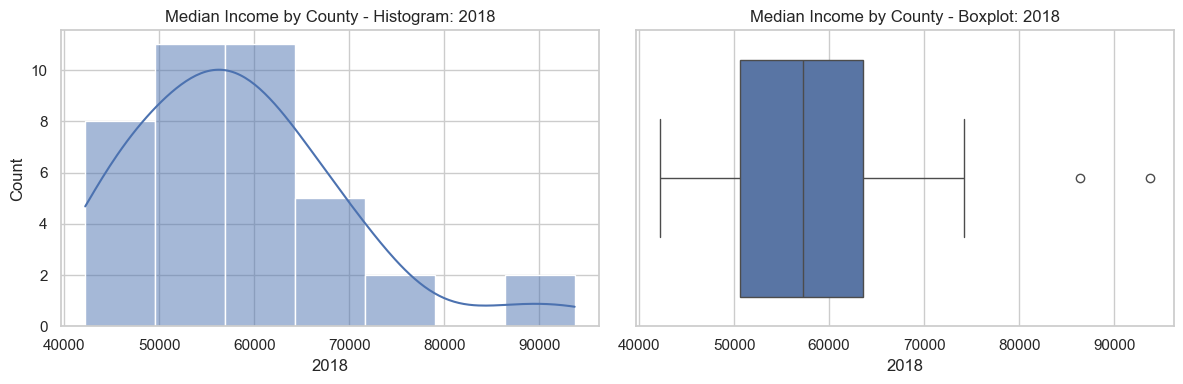


===== Median Income by County: CATEGORICAL VISUALIZATIONS =====


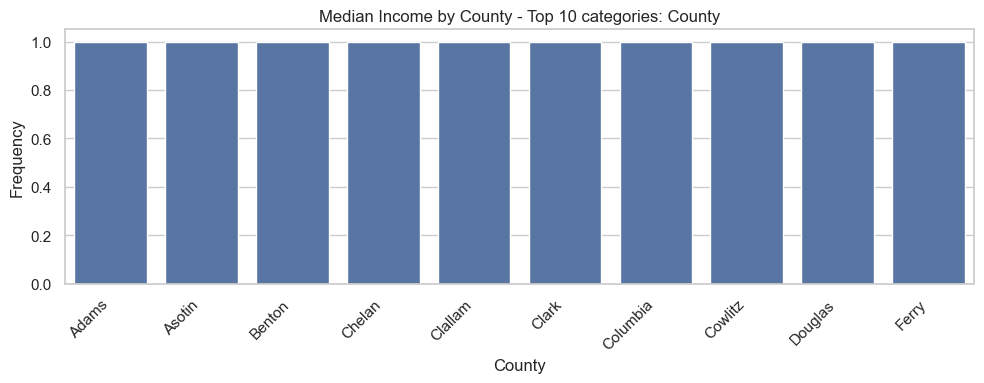

In [7]:
median_income = pd.read_csv("data/median_income_by_county.csv")

# ensure all columns to be floats
year_cols = [str(y) for y in range(2011, 2026)]
median_income[year_cols] = median_income[year_cols].astype(float)

run_eda(median_income, "Median Income by County")


### Data Quality Observations (to review)

- Potential issues to verify: missing income values, zero placeholders, and non-numeric income formatting.
- County consistency checks to inspect from outputs: county naming mismatches against other datasets.
- Fields likely to need cleaning later: county text standardization, year/date representation, and numeric conversion for income values.
- Fields likely irrelevant for PCA/clustering (without transformation): non-analytical identifiers or purely administrative labels.

### Notes for Future Merging (after data cleaning)

- Candidate merge keys later: county name and any available county code field.
- Potential merge problems later: county naming conventions (e.g., suffixes, punctuation, spacing).
- Candidate fields for future final features: median income level and related temporal indicators (if year columns exist), after cleaning and alignment.